In [83]:
import pandas as pd
import networkx as nx
from itertools import combinations
import matplotlib.pyplot as plt

In [2]:
news = pd.read_csv('../data/processed_news_2.csv')
leaks = pd.read_csv('../data/processed_leaks_2.csv')

In [3]:
news

,text,terrorism,security,espionage,communalism,keyword,response,year,month,day,countries
0,Starbucks violated federal labor law when it i...,False,False,False,False,False,"{\n ""metadata"": [\n {\n ""...",0,0,0,[]
1,The first suspect to plead guilty in Singapore...,False,False,False,False,False,"{\n ""metadata"": {\n ""earliest_date"":...",2019,4,2,"['Singapore', 'Cambodia', 'China']"
2,Meta has been fined a record-breaking €1.2 bil...,False,False,False,False,False,"{\n ""metadata"": [\n {\n ""...",0,0,0,"['European Union', 'United States']"
3,SINGAPORE: A 45-year-old man linked to Singapo...,False,False,False,False,False,"{\n ""metadata"": {\n ""earliest_date"":...",2019,4,30,['Singapore']
4,The Department of Education imposed a record $...,False,True,False,False,True,"{\n ""metadata"": [\n {\n ""earliest_dat...",2022,0,0,"['United States', 'Virginia']"
...,...,...,...,...,...,...,...,...,...,...,...
1504,NOT A SURPRISE FOR INDUSTRY FOLLOWERS..It is h...,False,False,False,False,False,"{\n ""metadata"": [\n {\n ""...",0,0,0,['Malaysia']
1505,"Ahead of the Tokyo 2020 Olympics, Japan prohib...",False,False,False,False,False,"{\n ""metadata"": [\n {\n ""...",2019,0,0,"['Japan', 'Australia', 'Singapore']"
1506,At a court hearing on Monday in the city of Ki...,False,False,False,False,False,"{\n ""metadata"": [\n ""earliest_date"":...",2015,7,1,['Germany']
1507,"Ray Mann, managing director of the West Wales ...",False,False,False,False,False,"{\n ""metadata"": [\n ""earliest_date"":...",2020,0,0,['United Kingdom']


In [75]:
g = nx.Graph()

In [77]:
for i, row in leaks.iterrows():
    if row['keyword']:
        try:
            ls = eval(row['countries'])
            g.add_nodes_from(ls)
            g.add_edges_from(combinations(ls, 2))
        except TypeError:
            continue
for i, row in news.iterrows():
    if row['keyword']:
        try:
            ls = eval(row['countries'])
            g.add_nodes_from(ls)
            g.add_edges_from(combinations(ls, 2))
        except TypeError:
            continue

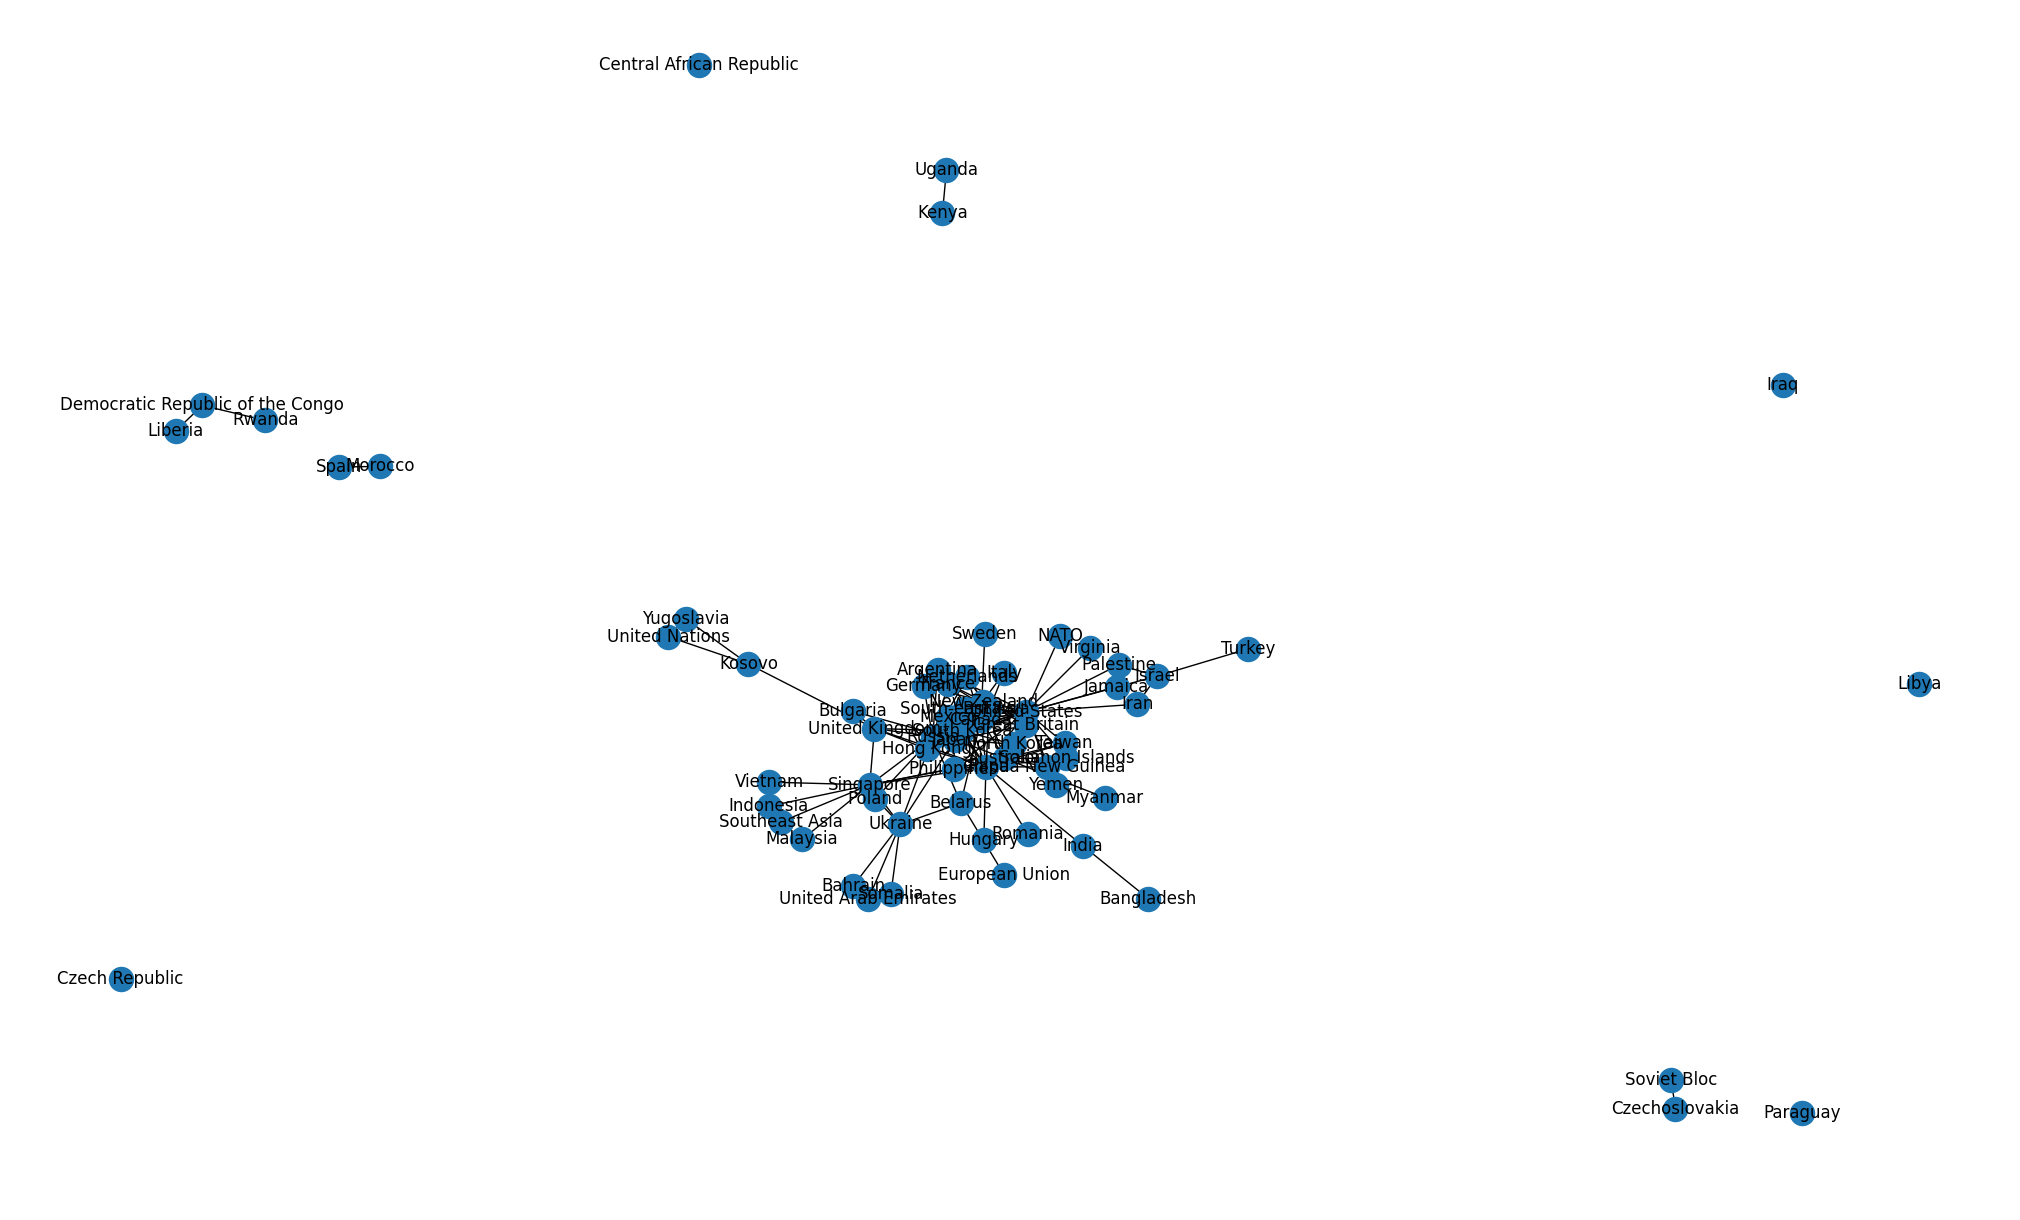

In [88]:
plt.figure(figsize=(20, 12))
nx.draw(g, with_labels=True)

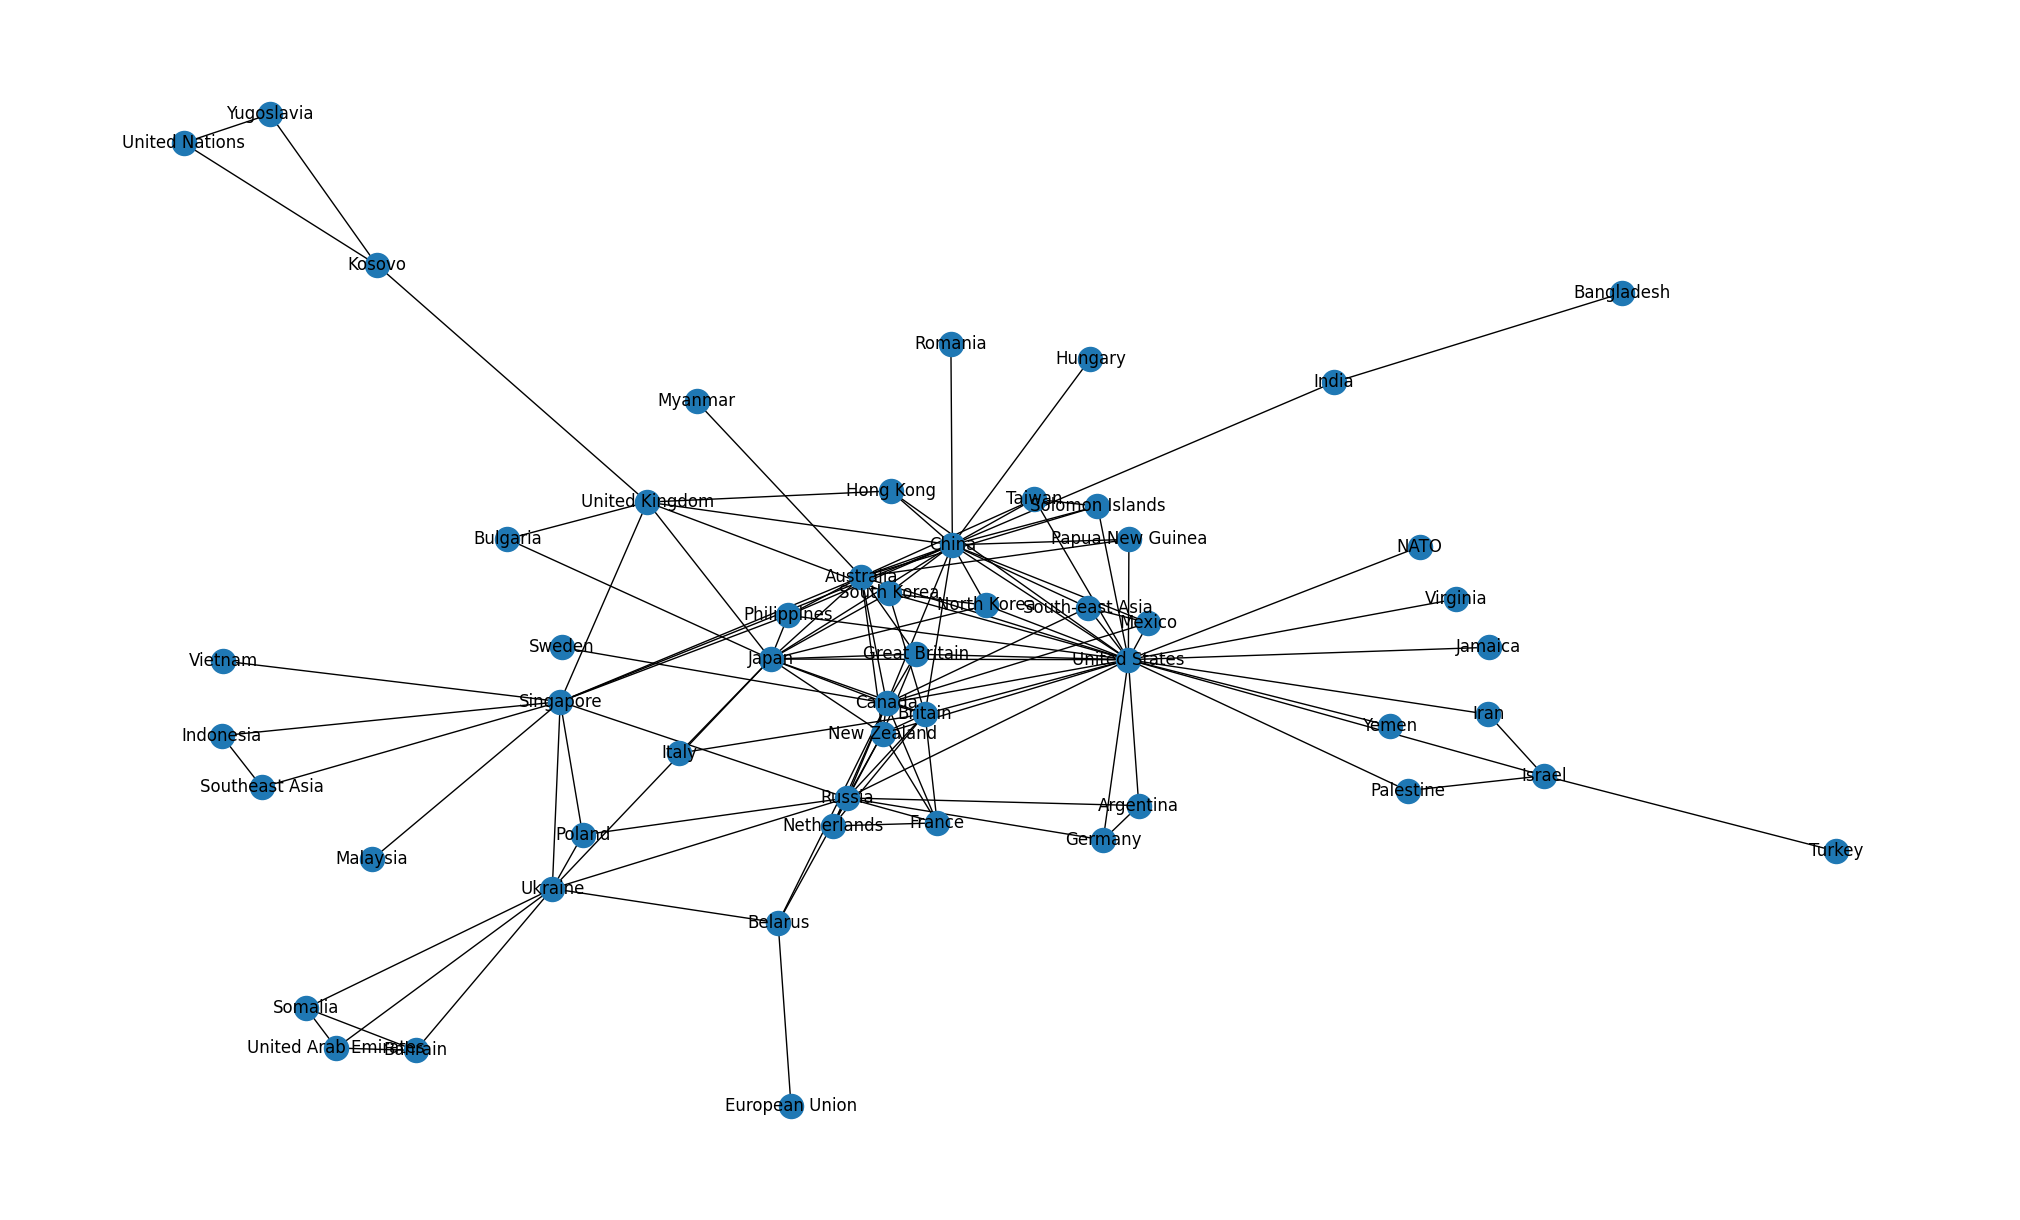

In [93]:
nx.node_connected_component(g, 'Singapore')
subg = g.subgraph(nx.subgraph(g, nx.node_connected_component(g, 'Singapore')))
plt.figure(figsize=(20, 12))
nx.draw(subg, with_labels=True)